In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [2]:
df = pd.read_csv("1.csv")

In [3]:
df.head()

,I am currently employed at least part-time,I identify as having a mental illness,Education,I have my own computer separate from a smart phone,I have been hospitalized before for my mental illness,How many days were you hospitalized for your mental illness,I am legally disabled,I have my regular access to the internet,I live with my parents,I have a gap in my resume,...,Obsessive thinking,Mood swings,Panic attacks,Compulsive behavior,Tiredness,Age,Gender,Household Income,Region,Device Type
0,0,0,High School or GED,0,0,0.0,0,1,0,1,...,1.0,0.0,1.0,0.0,0.0,30-44,Male,"$25,000-$49,999",Mountain,Android Phone / Tablet
1,1,1,Some Phd,1,0,0.0,0,1,0,0,...,0.0,0.0,1.0,0.0,1.0,18-29,Male,"$50,000-$74,999",East South Central,MacOS Desktop / Laptop
2,1,0,Completed Undergraduate,1,0,0.0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,30-44,Male,"$150,000-$174,999",Pacific,MacOS Desktop / Laptop
3,0,0,Some Undergraduate,1,0,NaN,0,1,1,1,...,0.0,0.0,0.0,0.0,0.0,30-44,Male,"$25,000-$49,999",New England,Windows Desktop / Laptop
4,1,1,Completed Undergraduate,1,1,35.0,1,1,0,1,...,1.0,1.0,1.0,1.0,1.0,30-44,Male,"$25,000-$49,999",East North Central,iOS Phone / Tablet


In [4]:
df.columns

Index(['I am currently employed at least part-time',
       'I identify as having a mental illness', 'Education',
       'I have my own computer separate from a smart phone',
       'I have been hospitalized before for my mental illness',
       'How many days were you hospitalized for your mental illness',
       'I am legally disabled', 'I have my regular access to the internet',
       'I live with my parents', 'I have a gap in my resume',
       'Annual income (including any social welfare programs) in USD',
       'I am unemployed', 'I read outside of work and school',
       'Annual income from social welfare programs', 'I receive food stamps',
       'I am on section 8 housing',
       'How many times were you hospitalized for your mental illness',
       'Lack of concentration', 'Anxiety', 'Depression', 'Obsessive thinking',
       'Mood swings', 'Panic attacks', 'Compulsive behavior', 'Tiredness',
       'Age', 'Gender', 'Household Income', 'Region', 'Device Type'],
      dtyp

In [5]:
df.shape

(334, 30)

In [6]:
df.rename(columns={'I identify as having a mental illness':'mentallyILL'}, inplace =True)

In [7]:
df = df.drop(['I am currently employed at least part-time','I have my own computer separate from a smart phone','I have been hospitalized before for my mental illness','How many days were you hospitalized for your mental illness',
       'I am legally disabled', 'I have my regular access to the internet',
       'I live with my parents', 'I have a gap in my resume',
       'Annual income (including any social welfare programs) in USD',
       'I am unemployed', 'I read outside of work and school',
       'Annual income from social welfare programs', 'I receive food stamps',
       'I am on section 8 housing',
       'How many times were you hospitalized for your mental illness','Household Income', 'Region', 'Device Type'],axis=1)

In [8]:
df.drop(df.tail(1).index,inplace=True)

In [9]:
df.head()

,mentallyILL,Education,Lack of concentration,Anxiety,Depression,Obsessive thinking,Mood swings,Panic attacks,Compulsive behavior,Tiredness,Age,Gender
0,0,High School or GED,1.0,1,1,1.0,0.0,1.0,0.0,0.0,30-44,Male
1,1,Some Phd,1.0,1,1,0.0,0.0,1.0,0.0,1.0,18-29,Male
2,0,Completed Undergraduate,0.0,0,0,0.0,0.0,0.0,0.0,0.0,30-44,Male
3,0,Some Undergraduate,0.0,0,0,0.0,0.0,0.0,0.0,0.0,30-44,Male
4,1,Completed Undergraduate,1.0,1,1,1.0,1.0,1.0,1.0,1.0,30-44,Male


In [10]:
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats

<Axes: xlabel='Education', ylabel='count'>

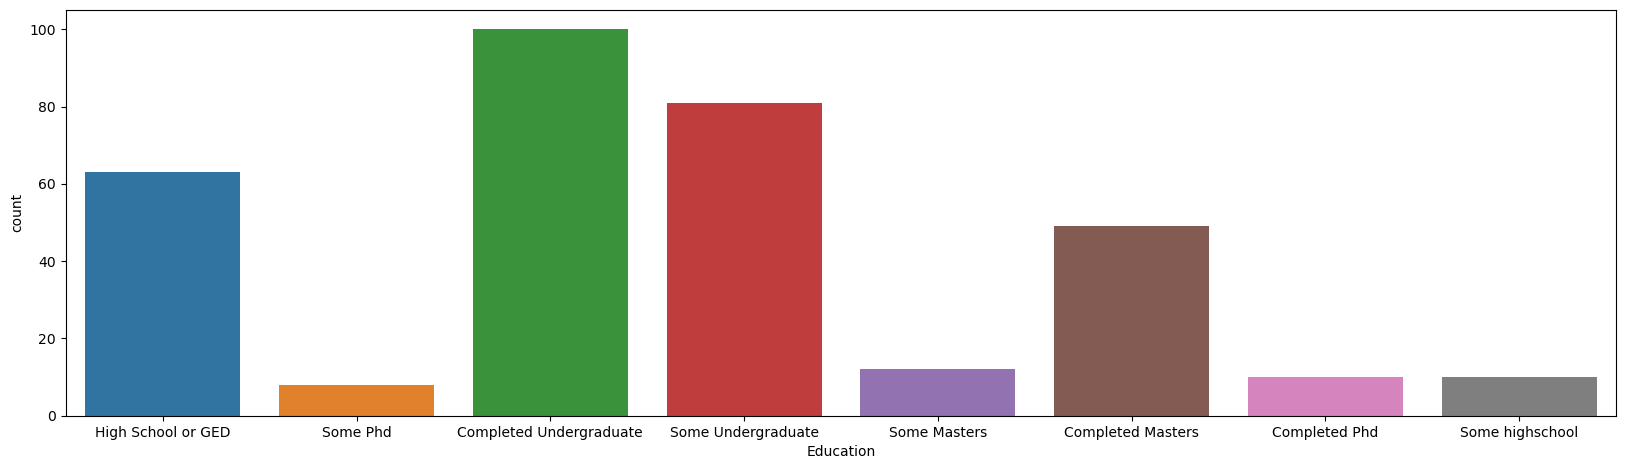

In [11]:
bar_size = (20,5.27)
fig , ax = plt.subplots(figsize=bar_size)
#sns.countplot(df.Education)
sns.countplot(data=df, x="Education", ax=ax)

In [12]:
# Education : {High School : 3, Phd : 4, Undergraduate : 2, }

In [13]:
sns.countplot(df.Gender)

ValueError: could not convert string to float: 'Male'

In [22]:
sns.countplot(df.Age)

ValueError: could not convert string to float: '30-44'

In [23]:
#replace gender -> Male = 1, Female = 0
df = df.replace(to_replace=['Female', 'Male'], value=[0, 1])
#replacing age with label encoder
df = df.replace(to_replace=['> 60', '45-60', '30-44','18-29'], value=[65, 52, 37, 23])
#replacing education with ranking, 0 is lowest educated 7 is highest
df = df.replace(to_replace=['Completed Phd', 'Some Phd', 'Completed Masters','Some\xa0Masters', 
                              'Completed Undergraduate', 'Some Undergraduate', 'High School or GED', 'Some highschool']
                              , value=[7, 6, 5, 4, 3, 2, 1, 0])

In [24]:
df.head()

,mentallyILL,Education,Lack of concentration,Anxiety,Depression,Obsessive thinking,Mood swings,Panic attacks,Compulsive behavior,Tiredness,Age,Gender
0,0,1,1.0,1,1,1.0,0.0,1.0,0.0,0.0,37,1
1,1,6,1.0,1,1,0.0,0.0,1.0,0.0,1.0,23,1
2,0,3,0.0,0,0,0.0,0.0,0.0,0.0,0.0,37,1
3,0,2,0.0,0,0,0.0,0.0,0.0,0.0,0.0,37,1
4,1,3,1.0,1,1,1.0,1.0,1.0,1.0,1.0,37,1


In [25]:
df.rename(columns={'Lack of concentration' : "concentration"},inplace='true')
df.rename(columns={'Obsessive thinking' : "overthinking"},inplace='true')
df.rename(columns={'Mood swings' : "mood"},inplace='true')
df.rename(columns={'Panic attacks' : "panic"},inplace='true')

In [26]:
df.head()

,mentallyILL,Education,concentration,Anxiety,Depression,overthinking,mood,panic,Compulsive behavior,Tiredness,Age,Gender
0,0,1,1.0,1,1,1.0,0.0,1.0,0.0,0.0,37,1
1,1,6,1.0,1,1,0.0,0.0,1.0,0.0,1.0,23,1
2,0,3,0.0,0,0,0.0,0.0,0.0,0.0,0.0,37,1
3,0,2,0.0,0,0,0.0,0.0,0.0,0.0,0.0,37,1
4,1,3,1.0,1,1,1.0,1.0,1.0,1.0,1.0,37,1


In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
X = df[['Education','concentration','Anxiety','Depression','overthinking','mood','panic','Compulsive behavior','Tiredness','Age','Gender']]

In [29]:
Y = df.mentallyILL

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=1)

In [31]:
# !st Regression Model
m1 = LogisticRegression()

In [32]:
m1.fit(x_train,y_train) 

/Users/vedantkokane/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [33]:
m1.score(x_test,y_test)  * 100

91.04477611940298

In [34]:
# decision tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
m2 = DecisionTreeClassifier()

In [39]:
m2.fit(x_train,y_train)

DecisionTreeClassifier()

In [40]:
m2.score(x_test,y_test) * 100

86.56716417910447

In [41]:
# Support Vector Machine

In [42]:
from sklearn.svm import SVC

In [43]:
m3 = SVC()

In [44]:
m3.fit(x_train,y_train)

SVC()

In [45]:
m3.score(x_test,y_test)  * 100

76.11940298507463

In [46]:
# gamma=10  --> score 0.8059701492537313
# no gamma --> score 0.8656716417910447

In [47]:
# Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
m4 = RandomForestClassifier()

In [50]:
m4.fit(x_train,y_train)

RandomForestClassifier()

In [51]:
m4.score(x_test,y_test)  * 100

86.56716417910447

In [52]:
# KNN

In [53]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
m5 = KNeighborsClassifier(n_neighbors=3) # 3 nearest neighbor are searched

In [55]:
m5.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [56]:
m5.score(x_test,y_test) * 100

91.04477611940298

In [64]:
# Comparison of all models by taking average
from sklearn.model_selection  import cross_val_score
m1_list = cross_val_score(LogisticRegression(),X,Y)
m2_list = cross_val_score(DecisionTreeClassifier(),X,Y)
m3_list = cross_val_score(SVC(),X,Y)
m4_list = cross_val_score(RandomForestClassifier(),X,Y)
m5_list = cross_val_score(KNeighborsClassifier(n_neighbors=3),X,Y)

/Users/vedantkokane/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
m1_list

array([0.88059701, 0.86567164, 0.89552239, 0.84848485, 0.87878788])

In [66]:
m2_list

array([0.8358209 , 0.85074627, 0.88059701, 0.81818182, 0.83333333])

In [67]:
m3_list

array([0.76119403, 0.76119403, 0.76119403, 0.77272727, 0.75757576])

In [68]:
m4_list

array([0.91044776, 0.82089552, 0.85074627, 0.81818182, 0.87878788])

In [69]:
m5_list

array([0.85074627, 0.79104478, 0.85074627, 0.83333333, 0.87878788])

In [70]:
# Average
m1_average = sum(m1_list)/len(m1_list)
m2_average = sum(m2_list)/len(m2_list)
m3_average = sum(m3_list)/len(m3_list)
m4_average = sum(m4_list)/len(m4_list)
m5_average = sum(m5_list)/len(m5_list)

In [71]:
m1_average * 100  # Logistic Regression

87.38127544097694

In [72]:
m2_average * 100 # Decision Tree

84.37358661239259

In [73]:
m3_average * 100 # Support Vector Machine

76.27770239710537

In [74]:
m4_average * 100 # Random Forest

85.58118498417005

In [75]:
m5_average * 100 # KNN

84.09317051108096

In [76]:
df

,mentallyILL,Education,concentration,Anxiety,Depression,overthinking,mood,panic,Compulsive behavior,Tiredness,Age,Gender
0,0,1,1.0,1,1,1.0,0.0,1.0,0.0,0.0,37,1
1,1,6,1.0,1,1,0.0,0.0,1.0,0.0,1.0,23,1
2,0,3,0.0,0,0,0.0,0.0,0.0,0.0,0.0,37,1
3,0,2,0.0,0,0,0.0,0.0,0.0,0.0,0.0,37,1
4,1,3,1.0,1,1,1.0,1.0,1.0,1.0,1.0,37,1
...,...,...,...,...,...,...,...,...,...,...,...,...
328,1,3,0.0,1,0,0.0,0.0,0.0,0.0,0.0,23,0
329,0,1,0.0,0,0,0.0,0.0,0.0,0.0,1.0,52,0
330,0,2,0.0,0,0,0.0,0.0,0.0,0.0,0.0,23,1
331,0,2,0.0,0,0,0.0,0.0,0.0,0.0,0.0,65,0


In [77]:
# confusion matrix for model 1 (Logistic regression)
y_predicted = m1.predict(x_test)
from sklearn.metrics import confusion_matrix

In [78]:
cm = confusion_matrix(y_test,y_predicted)
cm

array([[49,  2],
       [ 4, 12]])

Text(95.72222222222221, 0.5, 'Truth')

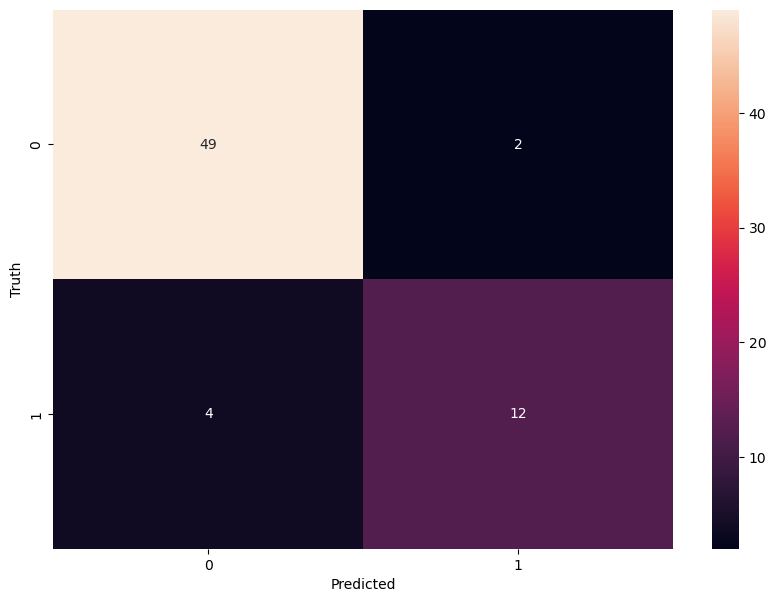

In [79]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")

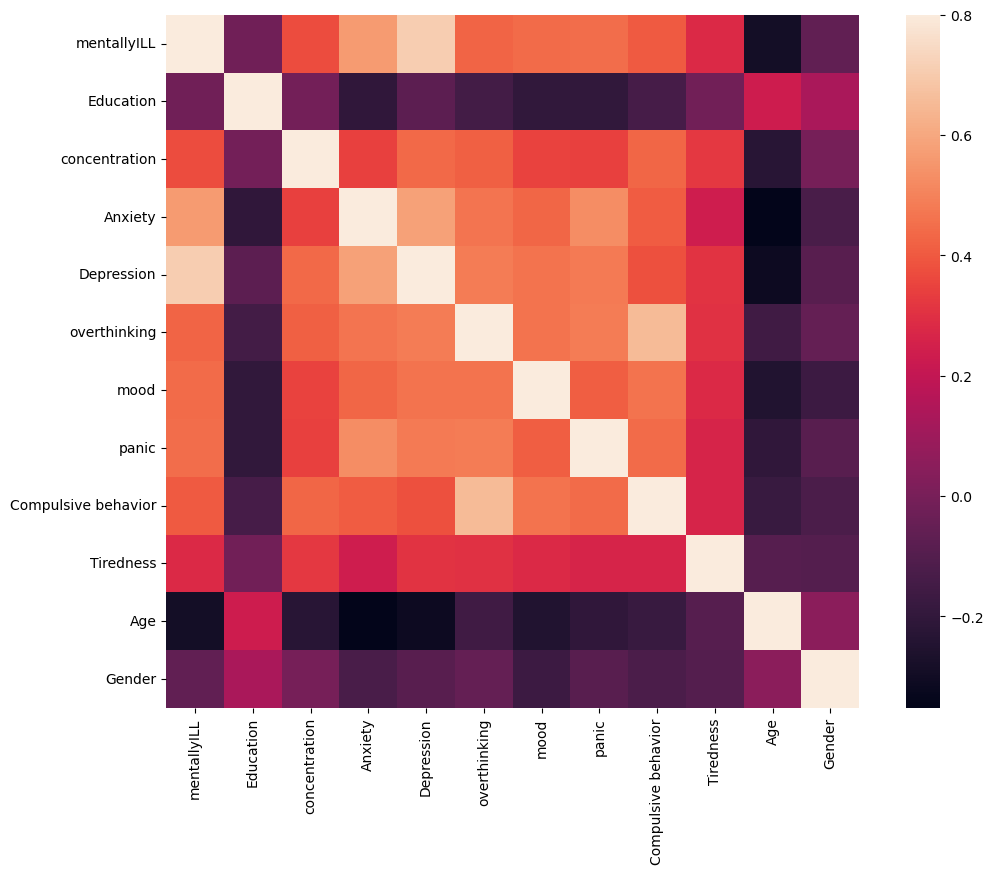

In [80]:
#Covariance Matrix
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sn.heatmap(corrmat, vmax=.8, square=True);
plt.show()

In [81]:
# Classification report
from sklearn.metrics import classification_report
rp = classification_report(y_test,y_predicted)
print(rp)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        51
           1       0.86      0.75      0.80        16

    accuracy                           0.91        67
   macro avg       0.89      0.86      0.87        67
weighted avg       0.91      0.91      0.91        67



In [82]:
# confusion matrix for model 4 (Random forest)
y_predicted = m4.predict(x_test)
from sklearn.metrics import confusion_matrix

In [83]:
cm = confusion_matrix(y_test,y_predicted)
cm

array([[46,  5],
       [ 4, 12]])

Text(95.72222222222221, 0.5, 'Truth')

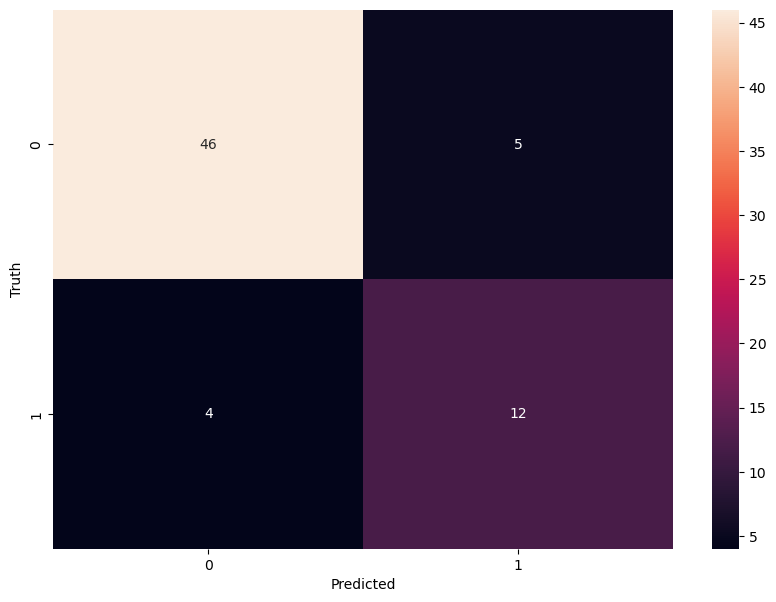

In [84]:
plt.figure(figsize = (10,7))
sn.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [85]:
import pickle
with open('ml_Model.pickle','wb') as f:
    pickle.dump(m1,f)

In [86]:
import coremltools
import joblib

scikit-learn version 1.3.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.1.2. Disabling scikit-learn conversion API.
/Users/vedantkokane/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [87]:
# Load your scikit-learn model
scikit_model = joblib.load('ml_Model.pickle')

In [88]:
pip install --upgrade scikit-learn coremltools


Note: you may need to restart the kernel to use updated packages.


In [89]:
import coremltools

In [90]:
coreml_model = coremltools.converters.sklearn.convert(scikit_model)


NameError: name '_tree' is not defined